# 1. Reproducibility Configuration

- ensures experimental reproducibility.
- *SEED = 42* used for Python, NumPy, and TensorFlow.
- helped to reduce randomness of dataset shuffling, weight initialization and augmentation operations during training phase.

In [ ]:
import os, random, numpy as np, tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Import Dependencies

- imported modules to support data preprocessing, model development, evaluation, and visualization.
- **TensorFlow / Keras** - implement and train the model
- **NumPy** - numerical computations
- **Matplotlib** and **Seaborn** - graphical representation and visualization


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os



## 3. Mount Google Drive

- *dataset* and *experiment files* stored in **Google Colab**
- this approach ease dataset management and a faster access during training and evaluation

&rarr; mount Google Drive to provide access to dataset, trained models for training and evaluation

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!unzip -qo "/content/drive/MyDrive/FER2013.zip" -d "/content/"

\## 4. FER2013 Loading and Preprocessing

- *FER2013* dataset was loaded from **train** and **test** directories using the *TensorFlow/Keras* **ImageDataGenerator** utility.

- images resized to **48x48 grayscale** to match RS-Xception requirements.

- during training (train_datagen), pixel values were normalized in range [0, 1] (`rescale=1./255`)

- *data augmentation techniques* used: rotation range, width and height shifts, zoom transormation
&rarr; create small variations to improve model robustness.

- for test dataset (`val_datagen`) - only normalization (`rescale=1./255`) applied to ensure the unbiased evaluation of the model

- training images (`train_gen`) were shuffled at each epoch, while test images (`val_gen`) were not shuffled.



In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

TRAIN_PATH = '/content/FER2013/train'
VAL_PATH = '/content/FER2013/test'



train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=16,
    shuffle=True,
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=16,
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


### Demonstrating Data Augmentation Techniques

- to understand and visualize data augmentation techniques
- use a randomly selected image from FER2013 dataset train path
- show for each image a plot which includes the image:
  - **Original Image**
  - **Rotation**
  - **Width Shift**
  - **Height Shift**
  - **Zoom**.

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as image_utils

# Define augmentation parameters from train_datagen
ROTATION_RANGE = 15
WIDTH_SHIFT_RANGE = 0.1
HEIGHT_SHIFT_RANGE = 0.1
ZOOM_RANGE = 0.1
FILL_MODE = 'nearest'

# Get all emotion subfolders
emotion_folders = [d for d in os.listdir(TRAIN_PATH) if os.path.isdir(os.path.join(TRAIN_PATH, d))]

# Randomly select an emotion
selected_emotion = random.choice(emotion_folders)
emotion_path = os.path.join(TRAIN_PATH, selected_emotion)

# Get all image files in the selected emotion folder
image_files = [f for f in os.listdir(emotion_path) if f.endswith(('.jpg', '.png', '.jpeg'))]

# Randomly select one image
selected_image_name = random.choice(image_files)
selected_image_path = os.path.join(emotion_path, selected_image_name)

# Load the image as grayscale (as per ImageDataGenerator config)
original_img = image_utils.load_img(selected_image_path, color_mode='grayscale', target_size=(48, 48))
original_img_array = image_utils.img_to_array(original_img)

# Expand dimensions to (1, H, W, C) for augmentation functions
original_img_batch = np.expand_dims(original_img_array, axis=0)

print(f"Selected image: {selected_image_path}")

Selected image: /content/FER2013/train/sad/Training_18843463.jpg


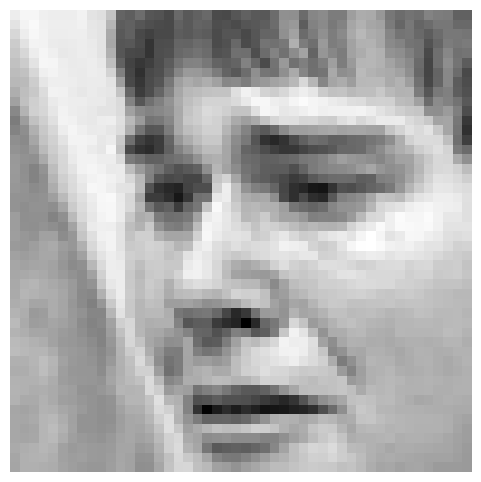

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(original_img_array.squeeze(), cmap='gray', interpolation='nearest') # Added interpolation
# plt.title('Original Image') # Removed title
plt.axis('off')
plt.show()

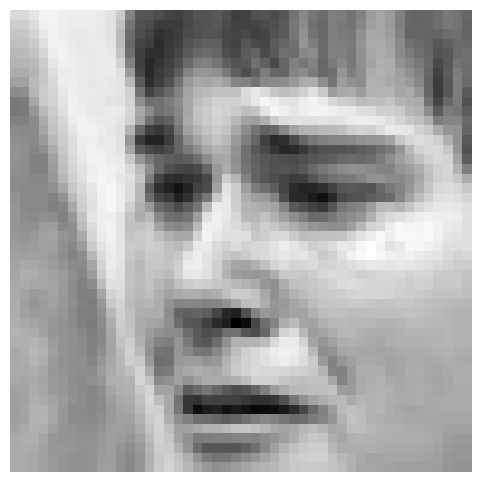

In [ ]:
augmented_img_rotated = image_utils.random_rotation(
    original_img_array,
    rg=ROTATION_RANGE,
    row_axis=0, col_axis=1, channel_axis=2,
    fill_mode=FILL_MODE
)

plt.figure(figsize=(6, 6))
plt.imshow(augmented_img_rotated.squeeze(), cmap='gray', interpolation='nearest') # Added interpolation
# plt.title(f'Rotated by {ROTATION_RANGE} degrees') # Removed title
plt.axis('off')
plt.show()

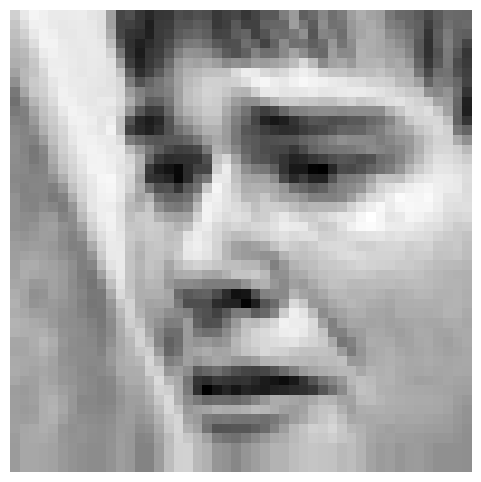

In [ ]:
augmented_img_width_shifted = image_utils.random_shift(
    original_img_array,
    wrg=WIDTH_SHIFT_RANGE,
    hrg=0.0,
    row_axis=0, col_axis=1, channel_axis=2,
    fill_mode=FILL_MODE
)

plt.figure(figsize=(6, 6))
plt.imshow(augmented_img_width_shifted.squeeze(), cmap='gray', interpolation='nearest') # Added interpolation
# plt.title(f'Width Shifted by {WIDTH_SHIFT_RANGE}') # Removed title
plt.axis('off')
plt.show()

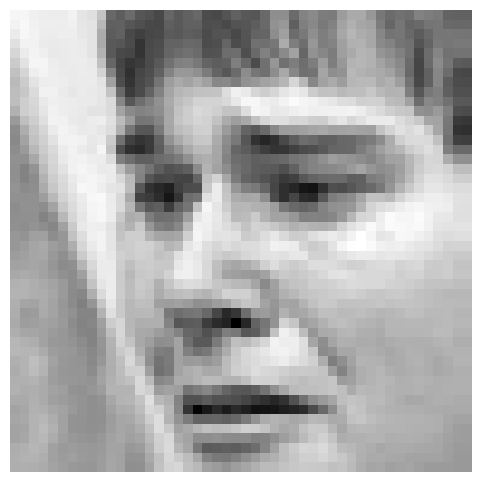

In [ ]:
augmented_img_height_shifted = image_utils.random_shift(
    original_img_array,
    wrg=0.0,
    hrg=HEIGHT_SHIFT_RANGE,
    row_axis=0, col_axis=1, channel_axis=2,
    fill_mode=FILL_MODE
)

plt.figure(figsize=(6, 6))
plt.imshow(augmented_img_height_shifted.squeeze(), cmap='gray', interpolation='nearest') # Added interpolation
# plt.title(f'Height Shifted by {HEIGHT_SHIFT_RANGE}') # Removed title
plt.axis('off')
plt.show()

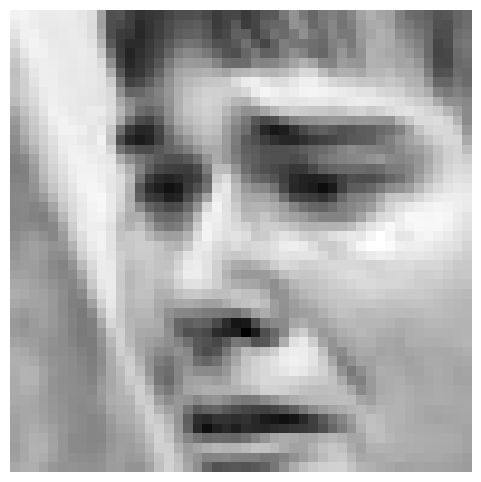

In [ ]:
augmented_img_zoomed = image_utils.random_zoom(
    original_img_array,
    zoom_range=(1.0 - ZOOM_RANGE, 1.0 + ZOOM_RANGE), # zoom_range is (lower, upper)
    row_axis=0, col_axis=1, channel_axis=2,
    fill_mode=FILL_MODE
)

plt.figure(figsize=(6, 6))
plt.imshow(augmented_img_zoomed.squeeze(), cmap='gray', interpolation='nearest') # Added interpolation
# plt.title(f'Zoomed by {ZOOM_RANGE}') # Removed title
plt.axis('off')
plt.show()

### Combined Data Augmentation Examples

- visualize all data augmentations in one plot for observing the slight differences of visualization.

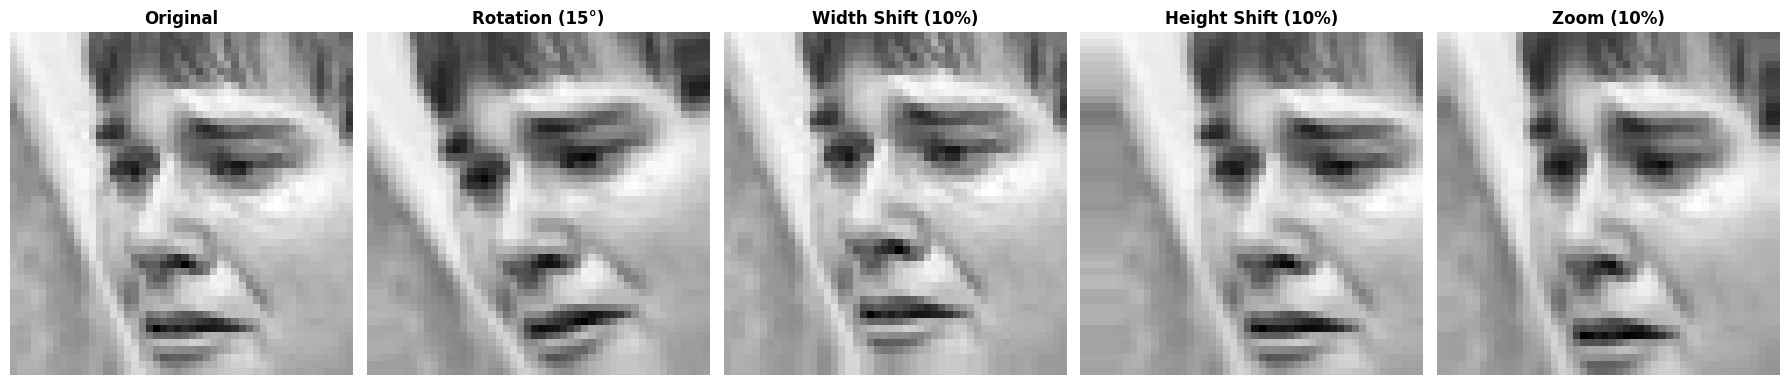

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(18, 4)) # Slightly reduced figure width for less whitespace

# Original Image
axes[0].imshow(original_img_array.squeeze(), cmap='gray', interpolation='nearest')
axes[0].set_title('Original', fontsize=12, fontweight='bold') # Smaller font size
axes[0].axis('off')

# Rotated Image
augmented_img_rotated_display = image_utils.random_rotation(
    original_img_array,
    rg=ROTATION_RANGE,
    row_axis=0, col_axis=1, channel_axis=2,
    fill_mode=FILL_MODE
)
axes[1].imshow(augmented_img_rotated_display.squeeze(), cmap='gray', interpolation='nearest')
axes[1].set_title(f'Rotation ({ROTATION_RANGE}°)', fontsize=12, fontweight='bold') # Smaller font size
axes[1].axis('off')

# Width Shifted Image
augmented_img_width_shifted_display = image_utils.random_shift(
    original_img_array,
    wrg=WIDTH_SHIFT_RANGE,
    hrg=0.0,
    row_axis=0, col_axis=1, channel_axis=2,
    fill_mode=FILL_MODE
)
axes[2].imshow(augmented_img_width_shifted_display.squeeze(), cmap='gray', interpolation='nearest')
axes[2].set_title(f'Width Shift ({WIDTH_SHIFT_RANGE*100:.0f}%)', fontsize=12, fontweight='bold') # Smaller font size, percentage format
axes[2].axis('off')

# Height Shifted Image
augmented_img_height_shifted_display = image_utils.random_shift(
    original_img_array,
    wrg=0.0,
    hrg=HEIGHT_SHIFT_RANGE,
    row_axis=0, col_axis=1, channel_axis=2,
    fill_mode=FILL_MODE
)
axes[3].imshow(augmented_img_height_shifted_display.squeeze(), cmap='gray', interpolation='nearest')
axes[3].set_title(f'Height Shift ({HEIGHT_SHIFT_RANGE*100:.0f}%)', fontsize=12, fontweight='bold') # Smaller font size, percentage format
axes[3].axis('off')

# Zoomed Image
augmented_img_zoomed_display = image_utils.random_zoom(
    original_img_array,
    zoom_range=(1.0 - ZOOM_RANGE, 1.0 + ZOOM_RANGE),
    row_axis=0, col_axis=1, channel_axis=2,
    fill_mode=FILL_MODE
)
axes[4].imshow(augmented_img_zoomed_display.squeeze(), cmap='gray', interpolation='nearest')
axes[4].set_title(f'Zoom ({ZOOM_RANGE*100:.0f}%)', fontsize=12, fontweight='bold') # Smaller font size, percentage format
axes[4].axis('off')

plt.tight_layout(w_pad=1.0) # Added w_pad to control width spacing explicitly
plt.show()

In [ ]:
import os

print("--- Training Image Counts by Emotion ---")
train_emotions = sorted(os.listdir(TRAIN_PATH))
for emotion in train_emotions:
    emotion_path = os.path.join(TRAIN_PATH, emotion)
    if os.path.isdir(emotion_path):
        num_images = len(os.listdir(emotion_path))
        print(f"  {emotion}: {num_images} images")

print("\n--- Test (Validation) Image Counts by Emotion ---")
test_emotions = sorted(os.listdir(VAL_PATH))
for emotion in test_emotions:
    emotion_path = os.path.join(VAL_PATH, emotion)
    if os.path.isdir(emotion_path):
        num_images = len(os.listdir(emotion_path))
        print(f"  {emotion}: {num_images} images")

--- Training Image Counts by Emotion ---
  angry: 3995 images
  disgust: 436 images
  fear: 4097 images
  happy: 7215 images
  neutral: 4965 images
  sad: 4830 images
  surprise: 3171 images

--- Test (Validation) Image Counts by Emotion ---
  angry: 958 images
  disgust: 111 images
  fear: 1024 images
  happy: 1774 images
  neutral: 1233 images
  sad: 1247 images
  surprise: 831 images


**Plotting the FER-2013 emotion-class distribution**

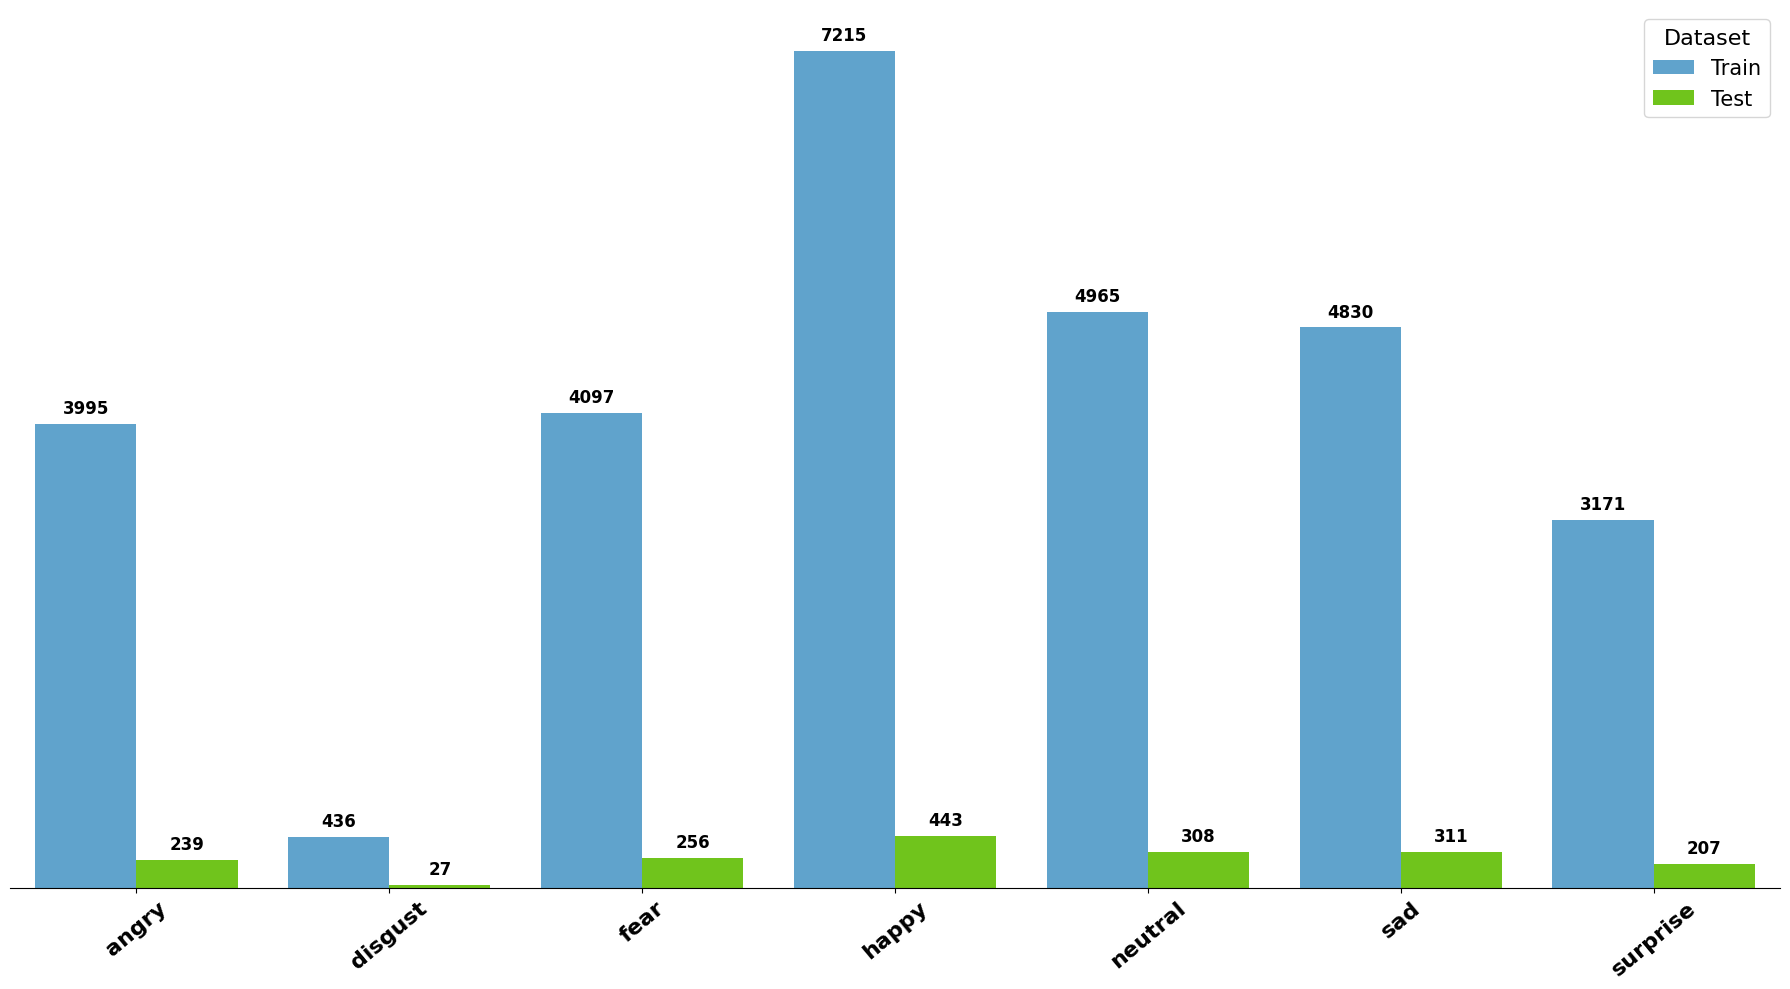

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data from the previous execution
train_data = {
    'Emotion': ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'],
    'Count': [3995, 436, 4097, 7215, 4965, 4830, 3171],
    'Dataset': ['Train'] * 7
}

test_data = {
    'Emotion': ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'],
    'Count': [239, 27, 256, 443, 308, 311, 207],
    'Dataset': ['Test'] * 7
}

df_train = pd.DataFrame(train_data)
df_test = pd.DataFrame(test_data)

# Combine the dataframes
df_combined = pd.concat([df_train, df_test])

# Light blue pentru Train, light green pentru Test
custom_palette = {'Train': '#4ea8de', 'Test': '#70e000'}

# Create the bar plot
plt.figure(figsize=(18, 10))
sns.barplot(x='Emotion', y='Count', hue='Dataset', data=df_combined, palette=custom_palette)

plt.xlabel('', fontsize=14)


plt.ylabel('', fontsize=14)
plt.yticks([], [])
sns.despine(left=True)

plt.xticks(rotation=40, ha='center', fontsize=16, fontweight='bold')

# Add bold text labels on top of the bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', label_type='edge', padding=5, fontsize=12, fontweight='bold')


plt.legend(title='Dataset', title_fontsize='16', fontsize='15', loc='upper right')

plt.tight_layout()
plt.show()


## 5. RS-Xception Model Architecture

- Proposed model - based on **RS-Xception** architecture, a lightweight CNN designed for FER.

- The architecture combines: **depthwise separable convolutions**, **residual connections**, and **squeeze-and-excitation (SE) attention mechanisms** in order to achieve an efficient balance between recognition performance and computational complexity.

- **Model Overview:**
  - *Input shape*: 48 × 48 × 1 grayscale facial images
  - *Initial feature extraction*: Convolutional layer with 32 filters followed by Batch Normalization and ReLU activation
  - *Feature extraction*: Five Residual Squeeze-and-Excitation Xception (RSX) modules with filter sizes [32, 64, 128, 256, and 512].
  - *Attention mechanism*: Squeeze-and-Excitation blocks used at each RSX module to emphasize informative feature channels
  - *Residual learning*: Shortcut connections improve feature propagation and training stability
  - *Spatial reduction*: Max Pooling layers to reduce spatial dimensions
  - Classifier: Final convolutional layer with 7 filters, followed by Global Average Pooling (GAP)and Softmax activation
  - Output: Probability distribution over the seven FER2013 emotion classes
  - **Observation**: The final convolutional layer directly produces one feature map for each emotion class. Global Average Pooling then aggregates each feature map into a single score, reducing the number of trainable parameters and improving suitability for mobile deployment.

In [ ]:

# RS-Xception Model Definition
from tensorflow.keras import layers, models

# Squeeze-and-Excitation Block (attention mechanism)
def SE_Block(inputs, ratio=8):
    filters = inputs.shape[-1]
    se = layers.GlobalAveragePooling2D()(inputs)
    se = layers.Dense(filters // ratio, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    x = layers.multiply([inputs, se])
    return x

# Residual + SE Module (as in Figure 3)  -> update like in paper
def RSX_Module(x, filters):
    shortcut = x

    # Channel projection if needed
    if x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Two Separable Convs
    x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.SeparableConv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # SE block
    x = SE_Block(x)

    # Residual connection
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    # Spatial reduction
    x = layers.MaxPooling2D((2, 2))(x)

    return x


# RS-Xception Full Model
def RS_Xception(input_shape=(48, 48, 1), num_classes=7):
    inputs = layers.Input(shape=input_shape)

    # Initial Conv layer (3x3)
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 5x RSX Modules with increasing filters
    for filters in [32, 64, 128, 256, 512]:
        x = RSX_Module(x, filters)

    # Final 3x3x7 Conv → GAP → Softmax
    x = layers.Conv2D(num_classes, (3, 3), padding='same')(x)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Activation('softmax')(x)

    model = models.Model(inputs, outputs)
    return model


# Create and summarize the model
model = RS_Xception()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 48,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 48, 48,    │      1,344 │ re_lu[0][0]       │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 48, 48,    │      1,344 │ re_lu_1[0][0]     │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ re_lu_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        132 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 48, 48,    │          0 │ re_lu_2[0][0],    │
│                     │ 32)               │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 48,    │          0 │ multiply[0][0],   │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 48, 48,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 24, 24,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 847,747 (3.23 MB)

 Trainable params: 841,795 (3.21 MB)

 Non-trainable params: 5,952 (23.25 KB)

## 6. Compile the model

- before training, the model was compiled by defining the *optimization strategy*, *loss function*, and *evaluation metrics*.

- **Adam** optimizer was selected due to its adaptive learning rate mechanism, which combines the advantages of momentum and adaptive gradient optimization.

- Initial **learning rate** of 0.001 - used to provide stable and efficient convergence during training.

- Loss function is **Categorical Cross-Entropy**, since task involve multi-class classification.

- **Accuracy** - used as the primary evaluation metric to monitor model performance throughout training and validation.

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Training Configuration and Callbacks

- before training, several strategies were employed to improve convergence, prevent overfitting and address class imbalance of FER2013 dataset.

- **Early Stopping** with `patience=20` monitors the validation loss and terminates training when no further improvement is observed. The best-performing model weights are automatically restored.

- **ReduceLROnPlateau** - decreases the learning rate when the validation loss stops improving, allowing the optimizer to perform finer parameter updates during later training stages.

- **Model Checkpoint** - saves the model that achieves the highest validation accuracy, ensuring that the best-performing version is preserved for evaluation and future deployment.

- **Class Weights** were computed automatically from the training dataset to compensate for class imbalance &rarr; assigns higher importance to underrepresented emotion classes during optimization.



In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
lr_decay = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5)

checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/RSX_v2_best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))



## 8. Model Training

- RS-Xception model - trained using the FER2013 dataset for a maximum of **150 epochs**.

- During training, **class weights** were applied to reduce the impact of class imbalance and improve recognition performance for less-represented emotions (*e.g. disgust, surprise*).

- The model was evaluated on the test dataset after each epoch - allowing the monitoring of validation accuracy (`val_accuracy`) and validation loss (`loss`) throughout the training process.

- **Callbacks** (*Early stopping*, *learning rate scheduling*, and *model checkpointing*) were employed to improve convergence and preserve the best-performing model.

In [ ]:
EPOCHS = 150

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, lr_decay, checkpoint]
)



Epoch 1/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2062 - loss: 1.9644
Epoch 1: val_accuracy improved from None to 0.29785, saving model to /content/drive/MyDrive/RSX_v2_best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/RSX_v2_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 111s 38ms/step - accuracy: 0.2538 - loss: 1.8477 - val_accuracy: 0.2979 - val_loss: 1.7807 - learning_rate: 0.0010
Epoch 2/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3635 - loss: 1.6295
Epoch 2: val_accuracy improved from 0.29785 to 0.32419, saving model to /content/drive/MyDrive/RSX_v2_best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/RSX_v2_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.3844 - loss: 1.5987 - val_accuracy: 0.3242 - val_loss: 1.8801 - learning_rate: 0.0010
Epoch 3/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4349 - loss: 1.4861
Epoch 3: val_accuracy improved from 0.32419 to 0.43801, saving model to /content/drive/MyDrive/RSX_v2_best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/RSX_v2_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.4423 - loss: 1.4641 - val_accuracy: 0.4380 - val_loss: 1.4558 - learning_rate: 0.0010
Epoch 4/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4600 - loss: 1.3953
Epoch 4: val_accuracy did not improve from 0.43801
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.4655 - loss: 1.4002 - val_accuracy: 0.4122 - val_loss: 1.6085 - learning_rate: 0.0010
Epoch 5/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4908 - loss: 1.3313
Epoch 5: val_accuracy improved from 0.43801 to 0.48844, saving model to /content/drive/MyDrive/RSX_v2_best_model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/RSX_v2_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.4952 - loss: 1.3223 - val_accuracy: 0.4884 - val_loss: 1.3339 - learning_rate: 0.0010
Epoch 6/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5078 - loss: 1.2714
Epoch 6: val_accuracy did not improve from 0.48844
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.5061 - loss: 1.2828 - val_accuracy: 0.4734 - val_loss: 1.4297 - learning_rate: 0.0010
Epoch 7/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5234 - loss: 1.2478
Epoch 7: val_accuracy did not improve from 0.48844
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.5244 - loss: 1.2422 - val_accuracy: 0.4822 - val_loss: 1.3497 - learning_rate: 0.0010
Epoch 8/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5266 - loss: 1.2231
Epoch 8: val_accuracy improved from 0.48844 to 0.53218, saving model to /content/drive/MyDrive/RSX_v2_best_model.h

...


Epoch 31: finished saving model to /content/drive/MyDrive/RSX_v2_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.7139 - loss: 0.6945 - val_accuracy: 0.6464 - val_loss: 1.0161 - learning_rate: 2.5000e-04
Epoch 32/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7290 - loss: 0.6598
Epoch 32: val_accuracy improved from 0.64642 to 0.65046, saving model to /content/drive/MyDrive/RSX_v2_best_model.h5



Epoch 32: finished saving model to /content/drive/MyDrive/RSX_v2_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.7251 - loss: 0.6714 - val_accuracy: 0.6505 - val_loss: 0.9980 - learning_rate: 2.5000e-04
Epoch 33/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7243 - loss: 0.6601
Epoch 33: val_accuracy did not improve from 0.65046
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.7254 - loss: 0.6600 - val_accuracy: 0.6477 - val_loss: 1.0258 - learning_rate: 2.5000e-04
Epoch 34/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7258 - loss: 0.6583
Epoch 34: val_accuracy did not improve from 0.65046
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7288 - loss: 0.6575 - val_accuracy: 0.6421 - val_loss: 1.0583 - learning_rate: 2.5000e-04
Epoch 35/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7292 - loss: 0.6490
Epoch 35: val_accuracy did not improve from 0.65046
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step


Epoch 38: finished saving model to /content/drive/MyDrive/RSX_v2_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.7519 - loss: 0.6068 - val_accuracy: 0.6544 - val_loss: 1.0280 - learning_rate: 1.2500e-04
Epoch 39/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7567 - loss: 0.5854
Epoch 39: val_accuracy did not improve from 0.65436
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.7529 - loss: 0.5939 - val_accuracy: 0.6527 - val_loss: 1.0324 - learning_rate: 1.2500e-04
Epoch 40/150
1792/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7576 - loss: 0.5854
Epoch 40: val_accuracy did not improve from 0.65436
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.7537 - loss: 0.5934 - val_accuracy: 0.6478 - val_loss: 1.0627 - learning_rate: 1.2500e-04
Epoch 41/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7579 - loss: 0.5902
Epoch 41: val_accuracy improved from 0.65436 to 0.65589, saving model to /content/drive/MyDrive/


Epoch 41: finished saving model to /content/drive/MyDrive/RSX_v2_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.7582 - loss: 0.5881 - val_accuracy: 0.6559 - val_loss: 1.0477 - learning_rate: 1.2500e-04
Epoch 42/150
1793/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7589 - loss: 0.5801
Epoch 42: val_accuracy did not improve from 0.65589
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.7596 - loss: 0.5827 - val_accuracy: 0.6538 - val_loss: 1.0573 - learning_rate: 1.2500e-04
Epoch 43/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7633 - loss: 0.5622
Epoch 43: val_accuracy did not improve from 0.65589
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.7611 - loss: 0.5696 - val_accuracy: 0.6527 - val_loss: 1.0596 - learning_rate: 6.2500e-05
Epoch 44/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7711 - loss: 0.5619
Epoch 44: val_accuracy improved from 0.65589 to 0.65910, saving model to /content/drive/MyDrive/


Epoch 44: finished saving model to /content/drive/MyDrive/RSX_v2_best_model.h5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.7671 - loss: 0.5686 - val_accuracy: 0.6591 - val_loss: 1.0381 - learning_rate: 6.2500e-05
Epoch 45/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7659 - loss: 0.5683
Epoch 45: val_accuracy did not improve from 0.65910
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.7696 - loss: 0.5611 - val_accuracy: 0.6481 - val_loss: 1.0659 - learning_rate: 6.2500e-05
Epoch 46/150
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7706 - loss: 0.5519
Epoch 46: val_accuracy did not improve from 0.65910
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.7723 - loss: 0.5532 - val_accuracy: 0.6566 - val_loss: 1.0435 - learning_rate: 6.2500e-05
Epoch 47/150
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7695 - loss: 0.5509
Epoch 47: val_accuracy did not improve from 0.65910
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step

## 9. Model Export and TensorFlow Lite Conversion

- After training, the best-performing RS-Xception model was saved in Keras format (`.h5`) for future reuse and evaluation.

- To enable deployment within the **Face2Mood mobile application**, the trained model was subsequently converted to the TensorFlow Lite (`.tflite`) format.

- **TensorFlow Lite** provides a lightweight representation of the model that is optimized for on-device inference, reducing storage requirements and enabling efficient execution for mobile hardware.

- Default TensorFlow Lite optimizations (`tf.lite.Optimize.DEFAULT`) were applied during the conversion process in order to improve deployment efficiency while preserving model performance.


In [ ]:
model.save('/content/drive/MyDrive/RSX_v2_best_model.h5')


converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]

tflite_model = converter.convert()  # conversion to .tflite

with open('/content/drive/MyDrive/RSX_V2_mobile_safe.tflite', 'wb') as f:
    f.write(tflite_model)

print("Saved RSX_V2_mobile_safe.tflite")

Saved artifact at '/tmp/tmpd6_yk2k8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 48, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  136619683916560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136619683917520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136619683919056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136619683915792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136619683911952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136619683920016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136619683919248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136619683920208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136619683919440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136619683921168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136619683921360:

## 10. Results, Graphs, and Metrics

### 10.1. Training Loss / Validation Loss Curves

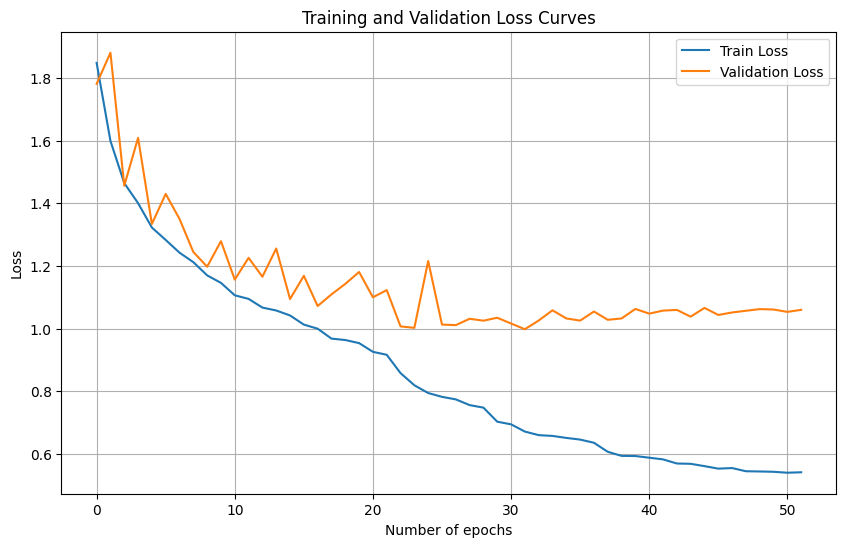

In [ ]:
import matplotlib.pyplot as plt

hist = history.history if hasattr(history, "history") else history

plt.figure(figsize=(10, 6))
plt.plot(hist['loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Validation Loss')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_epoch = np.argmin(hist['val_loss']) + 1

print("Loss Summary")
print("----------------------------")
print(f"Best Epoch (Validation Loss): {best_epoch}")
print(f"Best Validation Loss: {min(hist['val_loss']):.4f}")
print(f"Final Training Loss: {hist['loss'][-1]:.4f}")
print(f"Final Validation Loss: {hist['val_loss'][-1]:.4f}")

Loss Summary
----------------------------
Best Epoch (Validation Loss): 32
Best Validation Loss: 0.9980
Final Training Loss: 0.5416
Final Validation Loss: 1.0599


### 10.2. Training Accuracy / Validation Accuracy Curves

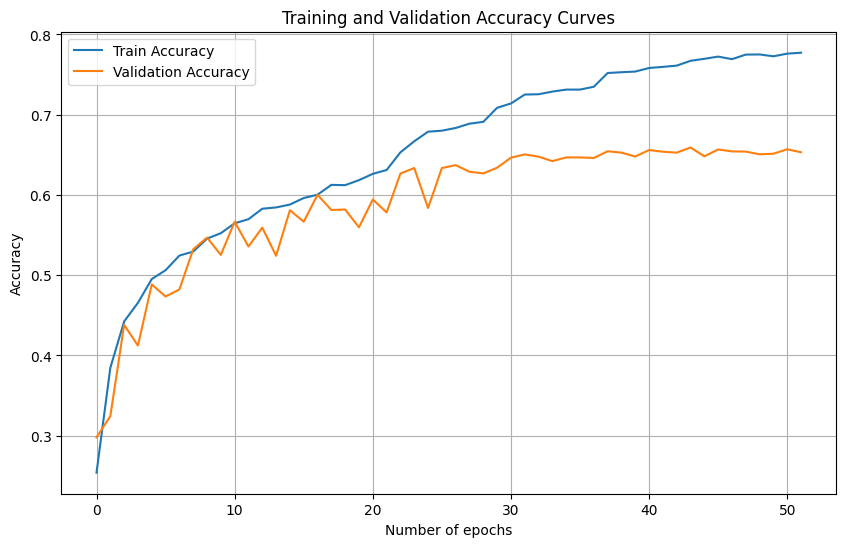

In [ ]:
import matplotlib.pyplot as plt

hist = history.history if hasattr(history, "history") else history

plt.figure(figsize=(10, 6))
plt.plot(hist['accuracy'], label='Train Accuracy')
plt.plot(hist['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Number of epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Curves')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_epoch = np.argmax(hist['val_accuracy']) + 1

print("Accuracy Summary:")
print("---------------------------------")
print(f"Best Epoch (Validation Accuracy): {best_epoch}")
print(f"Best Validation Accuracy: {max(hist['val_accuracy'])*100:.2f}%")
print(f"Final Training Accuracy: {hist['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {hist['val_accuracy'][-1]*100:.2f}%")

Accuracy Summary:
---------------------------------
Best Epoch (Validation Accuracy): 44
Best Validation Accuracy: 65.91%
Final Training Accuracy: 77.72%
Final Validation Accuracy: 65.31%


### 10.3.1 Raw Confusion Matrix

449/449 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step


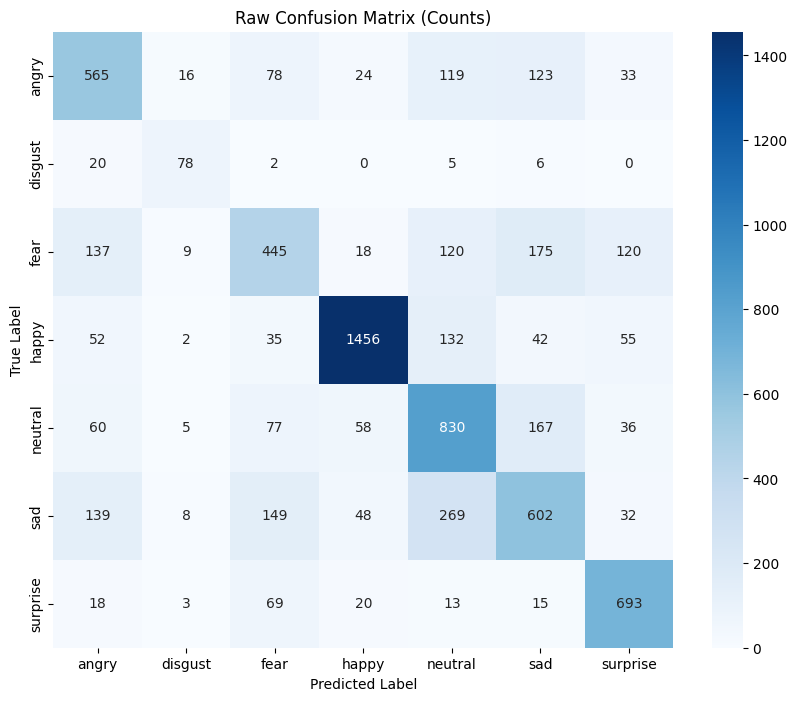

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Ensure val_gen is reset to avoid issues with previous iterations
val_gen.reset()

# Get true labels and predicted labels
y_true = val_gen.classes
y_pred_probabilities = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)

# Get class names from the generator
class_names = list(val_gen.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plotting the raw confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Raw Confusion Matrix (Counts)')
plt.show()

### 10.3.2 Normalized Confusion Matrix

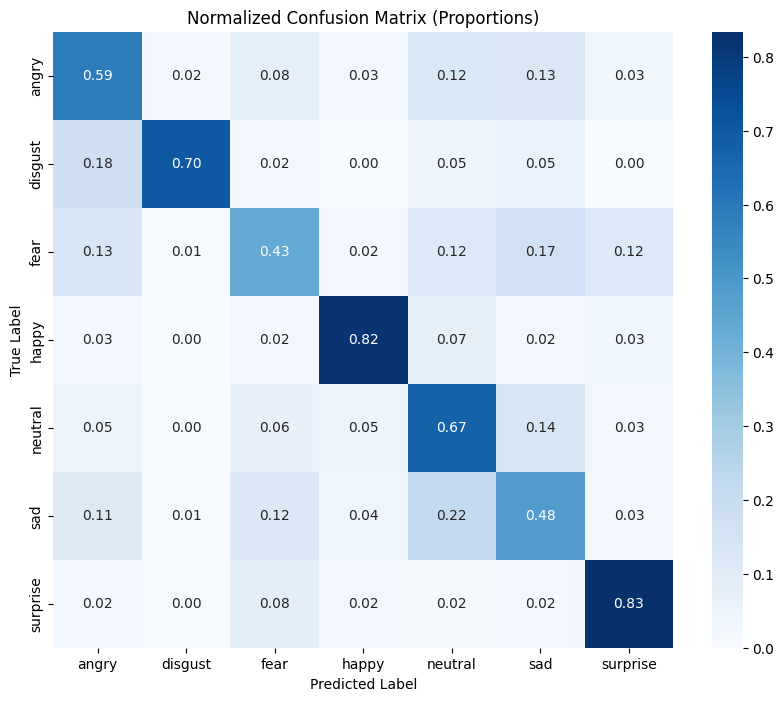

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Normalize the confusion matrix by rows (true labels) to get values between 0 and 1
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plotting the normalized confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Normalized Confusion Matrix (Proportions)')
plt.show()

### 10.4. Per-Class Accuracy

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Calculate per-class accuracy
cm_per_class = confusion_matrix(y_true, y_pred_classes)
per_class_accuracy = cm_per_class.diagonal() / cm_per_class.sum(axis=1)

# Create a DataFrame for per-class accuracy
per_class_accuracy_df = pd.DataFrame({
    'Emotion': class_names,
    'Accuracy': per_class_accuracy
})

print("Per-Class Accuracy:")
print(per_class_accuracy_df.to_markdown(index=False))

Per-Class Accuracy:
| Emotion   |   Accuracy |
|:----------|-----------:|
| angry     |   0.58977  |
| disgust   |   0.702703 |
| fear      |   0.43457  |
| happy     |   0.820744 |
| neutral   |   0.673155 |
| sad       |   0.482759 |
| surprise  |   0.833935 |


/tmp/ipykernel_8058/3105401808.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Emotion', y='Accuracy', data=per_class_accuracy_df, palette='viridis')


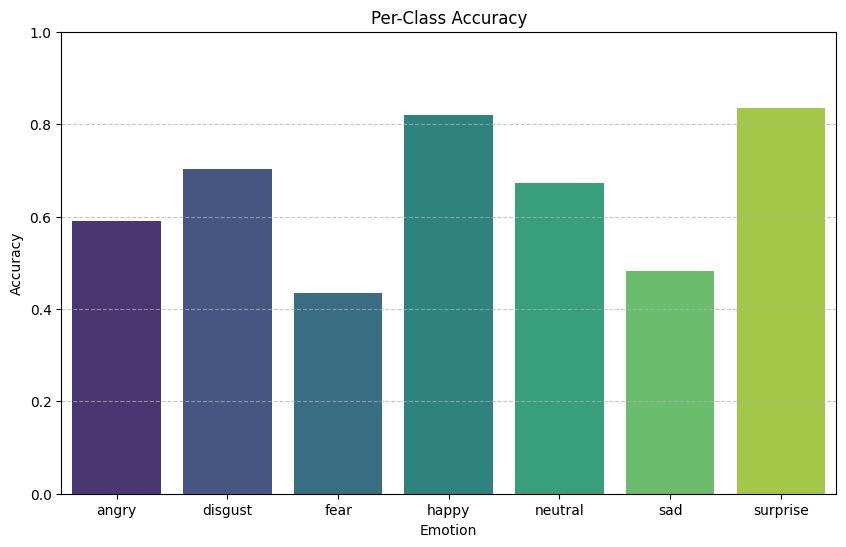

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting per-class accuracy
plt.figure(figsize=(10, 6))
sns.barplot(x='Emotion', y='Accuracy', data=per_class_accuracy_df, palette='viridis')
plt.xlabel('Emotion')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 10.5. Overall Metrics Table

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Calculate overall accuracy from test-set predictions
overall_accuracy = accuracy_score(
    y_true,
    y_pred_classes
) * 100

# Calculate macro precision, recall, f1 from the classification report
# y_true and y_pred_classes should be available from the Confusion Matrix/Classification Report steps
macro_precision = precision_score(y_true, y_pred_classes, average='macro')
macro_recall = recall_score(y_true, y_pred_classes, average='macro')
macro_f1 = f1_score(y_true, y_pred_classes, average='macro')

# Model Size (from TFLite conversion, if already done)
# Need to run TFLite conversion cell CgHX9urQe4tR first to get this
tflite_model_path = '/content/drive/MyDrive/RSX_V2_mobile_safe.tflite'
tflite_size_mb = os.path.getsize(tflite_model_path) / (1024 * 1024) if os.path.exists(tflite_model_path) else None

# Parameters Count
total_params = model.count_params()

# Create a dictionary for the table
metrics_data = {
    'Metric': [],
    'Value': []
}

if overall_accuracy is not None:
    metrics_data['Metric'].append('Accuracy')
    metrics_data['Value'].append(f"{overall_accuracy:.2f}%")

metrics_data['Metric'].append('Precision Macro')
metrics_data['Value'].append(f"{macro_precision:.3f}")
metrics_data['Metric'].append('Recall Macro')
metrics_data['Value'].append(f"{macro_recall:.3f}")
metrics_data['Metric'].append('F1 Macro')
metrics_data['Value'].append(f"{macro_f1:.3f}")

metrics_data['Metric'].append('Model Parameters')
metrics_data['Value'].append(f"{total_params:,}")

if tflite_size_mb is not None:
    metrics_data['Metric'].append('Model Size (TFLite)')
    metrics_data['Value'].append(f"{tflite_size_mb:.2f} MB")

metrics_df = pd.DataFrame(metrics_data)
print("Overall Metrics:")
print(metrics_df.to_markdown(index=False))

Overall Metrics:
| Metric              | Value   |
|:--------------------|:--------|
| Accuracy            | 65.05%  |
| Precision Macro     | 0.634   |
| Recall Macro        | 0.648   |
| F1 Macro            | 0.638   |
| Model Parameters    | 847,747 |
| Model Size (TFLite) | 0.91 MB |


### 10.6. Mobile Deployment Metrics

In [ ]:
import pandas as pd
import os
import numpy as np
import time

# Re-calculate inference time if not already in scope or if new run
# Using existing val_gen and model from previous cells
if 'val_gen' in locals() and 'model' in locals():
    val_gen.reset()
    val_images, _ = next(val_gen)

    num_predictions = 100
    inference_times = []

    # Warm-up run
    model.predict(val_images[:1], verbose=0)

    for _ in range(num_predictions):
        start_time = time.time()
        model.predict(val_images[:1], verbose=0)
        end_time = time.time()
        inference_times.append(end_time - start_time)

    mean_inference_time_ms = np.mean(inference_times) * 1000
else:
    mean_inference_time_ms = float('nan') # Indicate not available

# Model Size (from TFLite conversion, if already done)
tflite_model_path = '/content/drive/MyDrive/RSX_V2_mobile_safe.tflite'
tflite_size_mb = os.path.getsize(tflite_model_path) / (1024 * 1024) if os.path.exists(tflite_model_path) else None

# Parameters Count
total_params = model.count_params()

# Create a dictionary for the table
metrics_data = {
    'Metric': [],
    'Value': []
}

metrics_data['Metric'].append('Model Size (TFLite)')
metrics_data['Value'].append(f"{tflite_size_mb:.2f} MB") if tflite_size_mb is not None else metrics_data['Value'].append('N/A')

metrics_data['Metric'].append('Parameters')
metrics_data['Value'].append(f"{total_params:,}")

metrics_data['Metric'].append('Average Keras Inference Time (Colab)')
metrics_data['Value'].append(f"{mean_inference_time_ms:.2f} ms") if not np.isnan(mean_inference_time_ms) else metrics_data['Value'].append('N/A')

metrics_df = pd.DataFrame(metrics_data)
print("Mobile Deployment Metrics:")
print(metrics_df.to_markdown(index=False))

Mobile Deployment Metrics:
| Metric                               | Value    |
|:-------------------------------------|:---------|
| Model Size (TFLite)                  | 0.91 MB  |
| Parameters                           | 847,747  |
| Average Keras Inference Time (Colab) | 81.43 ms |


### 10.7. Precision, Recall, F1-Score

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(val_gen)
y_classes = np.argmax(y_pred, axis=1)
print(classification_report(val_gen.classes, y_classes, target_names=val_gen.class_indices.keys()))


449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

       angry       0.57      0.59      0.58       958
     disgust       0.64      0.70      0.67       111
        fear       0.52      0.43      0.47      1024
       happy       0.90      0.82      0.86      1774
     neutral       0.56      0.67      0.61      1233
         sad       0.53      0.48      0.51      1247
    surprise       0.72      0.83      0.77       831

    accuracy                           0.65      7178
   macro avg       0.63      0.65      0.64      7178
weighted avg       0.65      0.65      0.65      7178



## 11. Experimental Conclusions

- The `RSX_v2` model achieved the best overall performance among the evaluated RS-Xception variants and was therefore selected for deployment within the Face2Mood mobile application.

- The obtained results demonstrate that the combination of depthwise separable convolutions, residual connections, and squeeze-and-excitation attention mechanisms provides an effective balance between recognition accuracy and computational efficiency. The model achieved competitive performance on the FER2013 dataset while maintaining a lightweight size suitable for mobile deployment.

- The classification report and confusion matrix indicate that the model performs particularly well on the *Happy* and *Surprise* classes, while *Fear* and *Disgust* remains the most challenging emotion to classify accurately.

- Furthermore, the conversion to *TensorFlow Lite* and the small model size confirm suitability of the proposed architecture for real-time on-device inference in mobile environments.
